In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
df = pd.read_csv('GDSC_dataset.csv')
df2 = pd.read_csv('model_list_latest.csv')
gf = pd.read_csv('genomic_features.csv', low_memory=False)
df3 = pd.read_csv('Model.csv')

In [3]:
# To check how many rows x columns
'''
print(f"GDSC dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Passports file loaded: {df2.shape[0]:,} rows x {df2.shape[1]} columns")
print(f"Genomic features loaded: {gf.shape[0]:,} rows x {gf.shape[1]} columns")
print(f"DepMap model file loaded: {df3.shape[0]:,} rows x {df3.shape[1]} columns")'''

'\nprint(f"GDSC dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")\nprint(f"Passports file loaded: {df2.shape[0]:,} rows x {df2.shape[1]} columns")\nprint(f"Genomic features loaded: {gf.shape[0]:,} rows x {gf.shape[1]} columns")\nprint(f"DepMap model file loaded: {df3.shape[0]:,} rows x {df3.shape[1]} columns")'

In [4]:
# showin the columns presnet
'''
print("Columns in the main dataset:")
for i, col in enumerate(df.columns.tolist()):
    print(f"[{i:02d}] {col}")'''

'\nprint("Columns in the main dataset:")\nfor i, col in enumerate(df.columns.tolist()):\n    print(f"[{i:02d}] {col}")'

In [5]:
# SInce AUC and Z-score is useless, we drop them to avoid complications
LEAKAGE_COLS = ['AUC', 'Z_SCORE']
cols_to_drop = [c for c in LEAKAGE_COLS if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print("Leakage columns removed:")
print(cols_to_drop)
print(f"Current shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Leakage columns removed:
['AUC', 'Z_SCORE']
Current shape: 242,035 rows x 17 columns


In [6]:
# Checking if the TCGA cancer type is the same 'cancer type' column
CANCER_TYPE_COL = 'Cancer Type (matching TCGA label)'
if CANCER_TYPE_COL in df.columns:
    df[CANCER_TYPE_COL] = df[CANCER_TYPE_COL].replace({
        'COAD/READ': 'COREAD',
        'UNABLE TO CLASSIFY': 'UNCLASSIFIED',
    })
    print(f"Updated label inconsistencies in '{CANCER_TYPE_COL}'.")
else:
    print(f"Column '{CANCER_TYPE_COL}' was not found, so this step was skipped.")

Updated label inconsistencies in 'Cancer Type (matching TCGA label)'.


In [7]:
# The missing TCGA_DESC was filled by borrowing from the Cancer Type column 
# in the same dataset that had no TCGA label but did have a Cancer Type value were rescued this way. 
tcga_missing_before = df['TCGA_DESC'].isna().sum()
if CANCER_TYPE_COL in df.columns:
    df['tcga_was_crossfilled'] = (
        df['TCGA_DESC'].isna() & df[CANCER_TYPE_COL].notna()
    ).astype(int)

    df['TCGA_DESC'] = df['TCGA_DESC'].fillna(df[CANCER_TYPE_COL])

    tcga_missing_after = df['TCGA_DESC'].isna().sum()
    recovered = tcga_missing_before - tcga_missing_after

    df.drop(columns=[CANCER_TYPE_COL], inplace=True)

    print("Crossfill of TCGA_DESC from Cancer Type completed.")
    print(f"Missing before: {tcga_missing_before:,}")
    print(f"Recovered: {recovered:,}")
    print(f"Still missing: {tcga_missing_after:,}")
    print(f"Rows flagged as crossfilled: {df['tcga_was_crossfilled'].sum():,}")
else:
    df['tcga_was_crossfilled'] = 0
    print("Cancer Type column not found. tcga_was_crossfilled was set to 0.")


Crossfill of TCGA_DESC from Cancer Type completed.
Missing before: 1,067
Recovered: 360
Still missing: 707
Rows flagged as crossfilled: 360


In [8]:
# For the 707 rows still missing TCGA_DESC 
# after the Cancer Type crossfill, the broader GDSC Tissue 
# descriptor 1 value was used as a last-resort placeholder to 
# ensure no nulls remained going into the model.

still_missing_before = df['TCGA_DESC'].isna().sum()

mask_pass3 = df['TCGA_DESC'].isna() & df['GDSC Tissue descriptor 1'].notna()
df.loc[mask_pass3, 'TCGA_DESC'] = df.loc[mask_pass3, 'GDSC Tissue descriptor 1']

still_missing_after = df['TCGA_DESC'].isna().sum()
filled_pass3 = still_missing_before - still_missing_after

print("Fallback fill from Tissue descriptor 1 completed.")
print(f"Rows filled: {filled_pass3:,}")
print(f"Still missing: {still_missing_after:,}")

Fallback fill from Tissue descriptor 1 completed.
Rows filled: 707
Still missing: 0


In [9]:

cell_line_remap = {
    'MHH-CALL-4': 'ALL',
    'BONNA-12': 'UNCLASSIFIED',
    'U-CH2': 'UNCLASSIFIED',
    'NCCIT': 'UNCLASSIFIED',
}

for cell_line, new_label in cell_line_remap.items():
    mask = df['CELL_LINE_NAME'] == cell_line
    df.loc[mask, 'TCGA_DESC'] = new_label
    print(f"{cell_line} -> {new_label} ({mask.sum()} rows updated)")

remaining = df[df['TCGA_DESC'].isin(['leukemia', 'bone', 'urogenital_system'])]
print(f"Broad tissue labels still remaining: {len(remaining)}")
print(f"Unique TCGA labels now: {df['TCGA_DESC'].nunique()}")

MHH-CALL-4 -> ALL (179 rows updated)
BONNA-12 -> UNCLASSIFIED (179 rows updated)
U-CH2 -> UNCLASSIFIED (179 rows updated)
NCCIT -> UNCLASSIFIED (170 rows updated)
Broad tissue labels still remaining: 0
Unique TCGA labels now: 32


In [10]:
# To replace the OTHER with PRAD
df['TCGA_DESC'] = df['TCGA_DESC'].replace({'OTHER': 'PRAD'})

exceptions = ['BPH-1', 'NCI-H660']
for cell_line in exceptions:
    mask = df['CELL_LINE_NAME'] == cell_line
    df.loc[mask, 'TCGA_DESC'] = 'UNCLASSIFIED'
    print(f"{cell_line} -> UNCLASSIFIED ({mask.sum()} rows corrected)")

print(f"OTHER remaining: {(df['TCGA_DESC'] == 'OTHER').sum()}")
print(f"PRAD rows now: {(df['TCGA_DESC'] == 'PRAD').sum()}")
print(f"Unique TCGA labels now: {df['TCGA_DESC'].nunique()}")

BPH-1 -> UNCLASSIFIED (279 rows corrected)
NCI-H660 -> UNCLASSIFIED (179 rows corrected)
OTHER remaining: 0
PRAD rows now: 1676
Unique TCGA labels now: 31


Filling in the Tissue descriptior

In [11]:
DESC1_COL = 'GDSC Tissue descriptor 1'
DESC2_COL = 'GDSC Tissue descriptor 2'

df['COSMIC_ID'] = df['COSMIC_ID'].astype(str).str.strip()
df2['COSMIC_ID'] = df2['COSMIC_ID'].astype(str).str.strip()

desc1_missing_before = df[DESC1_COL].isna().sum()
desc2_missing_before = df[DESC2_COL].isna().sum()

print("Before descriptor fill:")
print(f"Descriptor 1 missing: {desc1_missing_before:,}")
print(f"Descriptor 2 missing: {desc2_missing_before:,}")

Before descriptor fill:
Descriptor 1 missing: 9,366
Descriptor 2 missing: 9,366


In [12]:
df['descriptor1_was_imputed'] = df[DESC1_COL].isna().astype(int)
df['descriptor2_was_imputed'] = df[DESC2_COL].isna().astype(int)

missing_d1_ids = set(df[df[DESC1_COL].isna()]['COSMIC_ID'].unique())
missing_d2_ids = set(df[df[DESC2_COL].isna()]['COSMIC_ID'].unique())
passport_ids = set(df2['COSMIC_ID'].unique())

print("Coverage check:")
print(f"Descriptor 1 missing cell lines: {len(missing_d1_ids):,}")
print(f"Covered by Passports: {len(missing_d1_ids & passport_ids):,}")
print(f"Not found in Passports: {len(missing_d1_ids - passport_ids):,}")
print()
print(f"Descriptor 2 missing cell lines: {len(missing_d2_ids):,}")
print(f"Covered by Passports: {len(missing_d2_ids & passport_ids):,}")
print(f"Not found in Passports: {len(missing_d2_ids - passport_ids):,}")

Coverage check:
Descriptor 1 missing cell lines: 39
Covered by Passports: 39
Not found in Passports: 0

Descriptor 2 missing cell lines: 39
Covered by Passports: 39
Not found in Passports: 0


In [13]:
df2_clean = df2[df2['COSMIC_ID'] != 'nan'].copy()

print(f"Passports rows with valid COSMIC_ID: {len(df2_clean):,}")
print(f"Rows dropped for missing COSMIC_ID: {len(df2) - len(df2_clean):,}")

passport_lookup = (
    df2_clean[['COSMIC_ID', 'tissue', 'cancer_type_detail']]
    .drop_duplicates(subset='COSMIC_ID', keep='first')
)

print(f"passport_lookup shape: {passport_lookup.shape}")

Passports rows with valid COSMIC_ID: 2,266
Rows dropped for missing COSMIC_ID: 0
passport_lookup shape: (1125, 3)


In [14]:
df = df.merge(passport_lookup, on='COSMIC_ID', how='left')

mask_d1 = df[DESC1_COL].isna() & df['tissue'].notna()
df.loc[mask_d1, DESC1_COL] = df.loc[mask_d1, 'tissue']

mask_d2 = df[DESC2_COL].isna() & df['cancer_type_detail'].notna()
df.loc[mask_d2, DESC2_COL] = df.loc[mask_d2, 'cancer_type_detail']

df.drop(columns=['tissue', 'cancer_type_detail'], inplace=True)

desc1_after_passport = df[DESC1_COL].isna().sum()
desc2_after_passport = df[DESC2_COL].isna().sum()

print("After Passports merge:")
print(f"Descriptor 1 missing: {desc1_after_passport:,}")
print(f"Descriptor 2 missing: {desc2_after_passport:,}")

After Passports merge:
Descriptor 1 missing: 0
Descriptor 2 missing: 0


In [15]:
print("Final descriptor check:")
print(f"Descriptor 1 missing: {df[DESC1_COL].isna().sum()}")
print(f"Descriptor 2 missing: {df[DESC2_COL].isna().sum()}")
print(f"Descriptor 1 unique values: {df[DESC1_COL].nunique()}")
print(f"Descriptor 2 unique values: {df[DESC2_COL].nunique()}")
print(f"descriptor1_was_imputed = 1 rows: {df['descriptor1_was_imputed'].sum():,}")
print(f"descriptor2_was_imputed = 1 rows: {df['descriptor2_was_imputed'].sum():,}")
print(f"Current dataframe shape: {df.shape}")

Final descriptor check:
Descriptor 1 missing: 0
Descriptor 2 missing: 0
Descriptor 1 unique values: 34
Descriptor 2 unique values: 78
descriptor1_was_imputed = 1 rows: 9,366
descriptor2_was_imputed = 1 rows: 9,366
Current dataframe shape: (242035, 19)


To fix MSI, Screen Medium and Growth Properties

In [16]:
FILL_UNKNOWN_COLS = [
    'Microsatellite instability Status (MSI)',
    'Screen Medium',
    'Growth Properties',
]

for col in FILL_UNKNOWN_COLS:
    missing_count = df[col].isna().sum()
    df[col] = df[col].fillna('Unknown')
    print(f"{col}")
    print(f"Filled {missing_count:,} missing values with 'Unknown'")
    print(f"Categories now: {sorted(df[col].unique().tolist())}")
    print()

print("Post-fill missing check:")
for col in FILL_UNKNOWN_COLS:
    print(f"{col}: {df[col].isna().sum()} missing")

Microsatellite instability Status (MSI)
Filled 12,353 missing values with 'Unknown'
Categories now: ['MSI-H', 'MSS/MSI-L', 'Unknown']

Screen Medium
Filled 9,366 missing values with 'Unknown'
Categories now: ['D/F12', 'R', 'Unknown']

Growth Properties
Filled 9,366 missing values with 'Unknown'
Categories now: ['Adherent', 'Semi-Adherent', 'Suspension', 'Unknown']

Post-fill missing check:
Microsatellite instability Status (MSI): 0 missing
Screen Medium: 0 missing
Growth Properties: 0 missing


In [17]:
MSI_COL = 'Microsatellite instability Status (MSI)'
GROWTH_COL = 'Growth Properties'

msi_label_map = {
    'MSS': 'MSS/MSI-L',
    'MSI': 'MSI-H',
}

msi_lookup = (
    df2_clean[['COSMIC_ID', 'msi_status']]
    .dropna(subset=['msi_status'])
    .drop_duplicates(subset='COSMIC_ID', keep='first')
    .copy()
)
msi_lookup['msi_status'] = msi_lookup['msi_status'].map(msi_label_map)

growth_lookup = (
    df2_clean[['COSMIC_ID', 'growth_properties']]
    .dropna(subset=['growth_properties'])
    .query("growth_properties != 'Unknown'")
    .drop_duplicates(subset='COSMIC_ID', keep='first')
)

msi_before = (df[MSI_COL] == 'Unknown').sum()

df = df.merge(msi_lookup, on='COSMIC_ID', how='left')
mask_msi = (df[MSI_COL] == 'Unknown') & df['msi_status'].notna()
df.loc[mask_msi, MSI_COL] = df.loc[mask_msi, 'msi_status']
df.drop(columns=['msi_status'], inplace=True)

msi_after = (df[MSI_COL] == 'Unknown').sum()

print("MSI upgrade completed.")
print(f"Unknown before: {msi_before:,}")
print(f"Rows upgraded: {msi_before - msi_after:,}")
print(f"Still Unknown: {msi_after:,}")
print(f"Categories now: {sorted(df[MSI_COL].unique().tolist())}")

MSI upgrade completed.
Unknown before: 12,353
Rows upgraded: 11,723
Still Unknown: 630
Categories now: ['MSI-H', 'MSS/MSI-L', 'Unknown']


In [18]:
growth_before = (df[GROWTH_COL] == 'Unknown').sum()

df = df.merge(growth_lookup, on='COSMIC_ID', how='left')
mask_growth = (df[GROWTH_COL] == 'Unknown') & df['growth_properties'].notna()
df.loc[mask_growth, GROWTH_COL] = df.loc[mask_growth, 'growth_properties']
df.drop(columns=['growth_properties'], inplace=True)

growth_after = (df[GROWTH_COL] == 'Unknown').sum()

print("Growth Properties upgrade completed.")
print(f"Unknown before: {growth_before:,}")
print(f"Rows upgraded: {growth_before - growth_after:,}")
print(f"Still Unknown: {growth_after:,}")
print(f"Categories now: {sorted(df[GROWTH_COL].unique().tolist())}")
print()
print("Post Step 7b missing check:")
print(f"{MSI_COL}: {df[MSI_COL].isna().sum()} missing")
print(f"{GROWTH_COL}: {df[GROWTH_COL].isna().sum()} missing")
print(f"Current dataframe shape: {df.shape}")

Growth Properties upgrade completed.
Unknown before: 9,366
Rows upgraded: 4,644
Still Unknown: 4,722
Categories now: ['Adherent', 'Semi-Adherent', 'Suspension', 'Unknown']

Post Step 7b missing check:
Microsatellite instability Status (MSI): 0 missing
Growth Properties: 0 missing
Current dataframe shape: (242035, 19)


Cleaning the Target Column

In [19]:
TARGET_COL = 'TARGET'

target_before = df[TARGET_COL].nunique()
print("Before cleaning TARGET:")
print(f"Unique values: {target_before:,}")
print(f"Missing values: {df[TARGET_COL].isna().sum():,}")

df[TARGET_COL] = df[TARGET_COL].str.strip()
df[TARGET_COL] = df[TARGET_COL].replace('', np.nan)

target_after = df[TARGET_COL].nunique()
print()
print("After cleaning TARGET:")
print(f"Unique values: {target_after:,}")
print(f"Reduction in unique values: {target_before - target_after}")
print(f"Missing values: {df[TARGET_COL].isna().sum():,}")
print()
print("Sample TARGET values:")
print(sorted(df[TARGET_COL].dropna().unique().tolist()[:20]))

Before cleaning TARGET:
Unique values: 185
Missing values: 27,155

After cleaning TARGET:
Unique values: 184
Reduction in unique values: 1
Missing values: 27,872

Sample TARGET values:
['ABL', 'Antimetabolite', 'BCL2, BCL-XL, BCL-W', 'CHEK1, CHEK2', 'CRBN', 'DNA crosslinker', 'EGFR', 'FLT3, JAK2, NTRK1, NTRK2, NTRK3', 'GSK3A, GSK3B', 'HDAC inhibitor Class I, IIa, IIb, IV', 'MEK1, MEK2', 'MTOR', 'Microtubule destabiliser', 'Microtubule stabiliser', 'NTRK1', 'PARP1, PARP2', 'PDGFR, KIT, VEGFR', 'Retinoic acid', 'SRC, ABL, TEC', 'TOP1']


In [20]:
# Normalizing the descriptors for the models
DESC1_COL = 'GDSC Tissue descriptor 1'

print(f"Descriptor 1 unique values before normalization: {df[DESC1_COL].nunique()}")

desc1_remap = {
    'Bladder': 'urogenital_system',
    'Bone': 'bone',
    'Central Nervous System': 'nervous_system',
    'Haematopoietic and Lymphoid': 'leukemia',
    'Head and Neck': 'aero_dig_tract',
    'Large Intestine': 'large_intestine',
    'Liver': 'digestive_system',
    'Lung': 'lung',
    'Pancreas': 'pancreas',
    'Skin': 'skin',
    'Small Intestine': 'digestive_system',
    'Soft Tissue': 'soft_tissue',
    'Stomach': 'digestive_system',
    'Testis': 'urogenital_system',
    'Thyroid': 'thyroid',
}

df[DESC1_COL] = df[DESC1_COL].replace(desc1_remap)

print(f"Descriptor 1 unique values after normalization: {df[DESC1_COL].nunique()}")
print("Final normalized Descriptor 1 values:")
print(sorted(df[DESC1_COL].dropna().unique().tolist()))

Descriptor 1 unique values before normalization: 34
Descriptor 1 unique values after normalization: 19
Final normalized Descriptor 1 values:
['aero_dig_tract', 'bone', 'breast', 'digestive_system', 'kidney', 'large_intestine', 'leukemia', 'lung', 'lung_NSCLC', 'lung_SCLC', 'lymphoma', 'myeloma', 'nervous_system', 'neuroblastoma', 'pancreas', 'skin', 'soft_tissue', 'thyroid', 'urogenital_system']


In [21]:
GENOMIC_FLAG_COLS = ['CNA', 'Gene Expression', 'Methylation']

for col in GENOMIC_FLAG_COLS:
    missing_count = df[col].isna().sum()
    df[col] = df[col].fillna('Unknown')
    print(f"{col}")
    print(f"Filled {missing_count:,} missing values with 'Unknown'")
    print(f"Categories now: {sorted(df[col].unique().tolist())}")
    print()

print("Post-fill missing check:")
for col in GENOMIC_FLAG_COLS:
    print(f"{col}: {df[col].isna().sum()} missing")

CNA
Filled 9,366 missing values with 'Unknown'
Categories now: ['N', 'Unknown', 'Y']

Gene Expression
Filled 9,366 missing values with 'Unknown'
Categories now: ['N', 'Unknown', 'Y']

Methylation
Filled 9,366 missing values with 'Unknown'
Categories now: ['N', 'Unknown', 'Y']

Post-fill missing check:
CNA: 0 missing
Gene Expression: 0 missing
Methylation: 0 missing


Genomic Features change

In [22]:
gf_wide = gf.pivot_table(
    index='COSMIC ID',
    columns='Genetic Feature',
    values='IS Mutated',
    aggfunc='max',
    fill_value=0
).reset_index()

gf_wide.rename(columns={'COSMIC ID': 'COSMIC_ID'}, inplace=True)
gf_wide.columns.name = None

print(f"Pivoted genomic feature table shape: {gf_wide.shape}")
print(f"Sample columns: {gf_wide.columns[:5].tolist()}")
print(f"Sample COSMIC_ID values: {gf_wide['COSMIC_ID'].head(5).tolist()}")

Pivoted genomic feature table shape: (969, 736)
Sample columns: ['COSMIC_ID', 'ABCB1_mut', 'ABL2_mut', 'ACACA_mut', 'ACVR1B_mut']
Sample COSMIC_ID values: [683667, 684052, 684057, 684059, 684062]


In [23]:
df['COSMIC_ID'] = df['COSMIC_ID'].astype(str).str.strip()
gf_wide['COSMIC_ID'] = gf_wide['COSMIC_ID'].astype(str).str.strip()

df_genomic = df.merge(gf_wide, on='COSMIC_ID', how='left')

genomic_cols = [c for c in gf_wide.columns if c != 'COSMIC_ID']
df_genomic[genomic_cols] = df_genomic[genomic_cols].fillna(0)

print(f"Shape before genomic merge: {df.shape}")
print(f"Shape after genomic merge: {df_genomic.shape}")
print(f"New genomic columns added: {len(genomic_cols):,}")

Shape before genomic merge: (242035, 19)
Shape after genomic merge: (242035, 754)
New genomic columns added: 735


Remapping the TCGA Unclassifed

In [24]:
# Basic Remapping based on everything

TCGA_COL = 'TCGA_DESC'
DESC1_COL = 'GDSC Tissue descriptor 1'
DESC2_COL = 'GDSC Tissue descriptor 2'

unclassified_before = (df[TCGA_COL] == 'UNCLASSIFIED').sum()

desc2_remap = {
    'breast': 'BRCA',
    'pancreas': 'PAAD',
    'head and neck': 'HNSC',
    'Parotid Gland Mucoepidermoid Carcinoma': 'HNSC',
    'kidney': 'KIRC',
    'Childhood B Acute Lymphoblastic Leukemia': 'ALL',
    'stomach': 'STAD',
    'biliary_tract': 'CHOL',
    'ovary': 'OV',
    'endometrium': 'UCEC',
    'uterus': 'UCEC',
    'prostate': 'PRAD',
    'cervix': 'CESC',
    'testis': 'TGCT',
    'Testicular Embryonal Carcinoma': 'TGCT',
    'lung_NSCLC_adenocarcinoma': 'LUAD',
    'Burkitt_lymphoma': 'DLBC',
}

unclassified_mask = df[TCGA_COL] == 'UNCLASSIFIED'

remapped_counts = {}
for desc2_val, tcga_label in desc2_remap.items():
    mask = unclassified_mask & (df[DESC2_COL] == desc2_val)
    count = mask.sum()
    if count > 0:
        df.loc[mask, TCGA_COL] = tcga_label
        remapped_counts[desc2_val] = (tcga_label, count)
    unclassified_mask = df[TCGA_COL] == 'UNCLASSIFIED'

unclassified_after = (df[TCGA_COL] == 'UNCLASSIFIED').sum()

print("Descriptor-based UNCLASSIFIED remap completed.")
print(f"UNCLASSIFIED before: {unclassified_before:,}")
print(f"UNCLASSIFIED after: {unclassified_after:,}")
print(f"Rows remapped: {unclassified_before - unclassified_after:,}")
print()
print("Remapped rows by Descriptor 2:")
print(f"{'Descriptor 2':<45} {'TCGA':<10} {'Rows':>6}")
print("-" * 65)
for desc2_val, (tcga_label, count) in remapped_counts.items():
    print(f"{desc2_val:<45} {tcga_label:<10} {count:>6,}")

print()
print("Remaining UNCLASSIFIED breakdown by Descriptor 1:")
print(df[df[TCGA_COL] == 'UNCLASSIFIED'][DESC1_COL].value_counts(dropna=False).to_string())

Descriptor-based UNCLASSIFIED remap completed.
UNCLASSIFIED before: 46,397
UNCLASSIFIED after: 33,582
Rows remapped: 12,815

Remapped rows by Descriptor 2:
Descriptor 2                                  TCGA         Rows
-----------------------------------------------------------------
breast                                        BRCA          282
pancreas                                      PAAD          534
head and neck                                 HNSC          279
Parotid Gland Mucoepidermoid Carcinoma        HNSC          279
kidney                                        KIRC          279
Childhood B Acute Lymphoblastic Leukemia      ALL           278
stomach                                       STAD          929
biliary_tract                                 CHOL        1,008
ovary                                         OV          2,268
endometrium                                   UCEC          558
uterus                                        UCEC          557
prostate  

In [25]:
# Now remapping using DepMap

df3['COSMICID'] = (
    df3['COSMICID']
    .astype(str).str.strip()
    .str.replace('.0', '', regex=False)
)
df['COSMIC_ID'] = df['COSMIC_ID'].astype(str).str.strip()

depmap_lookup = (
    df3[['COSMICID', 'OncotreePrimaryDisease', 'OncotreeCode']]
    .dropna(subset=['COSMICID'])
    .query("COSMICID != 'nan'")
    .drop_duplicates(subset='COSMICID', keep='first')
    .rename(columns={'COSMICID': 'COSMIC_ID'})
)

unclassified_mask = df['TCGA_DESC'] == 'UNCLASSIFIED'
unclassified_before = unclassified_mask.sum()

df = df.merge(depmap_lookup, on='COSMIC_ID', how='left')

oncotree_code_remap = {
    'AML': 'LAML',
    'TLL': 'ALL',
    'DLBCLNOS': 'DLBC',
    'BL': 'DLBC',
    'NHL': 'DLBC',
    'LUAD': 'LUAD',
    'LUAS': 'LUSC',
    'STAD': 'STAD',
}

oncotree_disease_remap = {
    'B-Cell Acute Lymphoblastic Leukemia': 'ALL',
    'Acute Myeloid Leukemia': 'LAML',
    'Mature B-Cell Neoplasms': 'DLBC',
    'Non-Hodgkin Lymphoma': 'DLBC',
    'T-Lymphoblastic Leukemia/Lymphoma': 'ALL',
    'Esophagogastric Adenocarcinoma': 'STAD',
}

unclassified_mask = df['TCGA_DESC'] == 'UNCLASSIFIED'
remapped_code = {}
remapped_disease = {}

for code, tcga_label in oncotree_code_remap.items():
    mask = unclassified_mask & (df['OncotreeCode'] == code)
    count = mask.sum()
    if count > 0:
        df.loc[mask, 'TCGA_DESC'] = tcga_label
        remapped_code[code] = (tcga_label, count)
    unclassified_mask = df['TCGA_DESC'] == 'UNCLASSIFIED'

for disease, tcga_label in oncotree_disease_remap.items():
    mask = unclassified_mask & (df['OncotreePrimaryDisease'] == disease)
    count = mask.sum()
    if count > 0:
        df.loc[mask, 'TCGA_DESC'] = tcga_label
        remapped_disease[disease] = (tcga_label, count)
    unclassified_mask = df['TCGA_DESC'] == 'UNCLASSIFIED'

df.drop(columns=['OncotreePrimaryDisease', 'OncotreeCode'], inplace=True)

unclassified_after = (df['TCGA_DESC'] == 'UNCLASSIFIED').sum()

print("DepMap remap completed.")
print(f"UNCLASSIFIED before: {unclassified_before:,}")
print(f"UNCLASSIFIED after: {unclassified_after:,}")
print(f"Rows remapped: {unclassified_before - unclassified_after:,}")

print()
print("Remapped through OncotreeCode:")
print(f"{'OncotreeCode':<15} {'TCGA':<10} {'Rows':>6}")
print("-" * 35)
for code, (tcga_label, count) in remapped_code.items():
    print(f"{code:<15} {tcga_label:<10} {count:>6,}")

print()
print("Remapped through OncotreePrimaryDisease:")
print(f"{'OncotreePrimaryDisease':<45} {'TCGA':<10} {'Rows':>6}")
print("-" * 65)
for disease, (tcga_label, count) in remapped_disease.items():
    print(f"{disease:<45} {tcga_label:<10} {count:>6,}")

print()
print("Final UNCLASSIFIED breakdown by Descriptor 1:")
print(df[df['TCGA_DESC'] == 'UNCLASSIFIED']['GDSC Tissue descriptor 1'].value_counts(dropna=False).to_string())

print()
print("Final UNCLASSIFIED breakdown by Descriptor 2:")
print(df[df['TCGA_DESC'] == 'UNCLASSIFIED']['GDSC Tissue descriptor 2'].value_counts(dropna=False).to_string())

DepMap remap completed.
UNCLASSIFIED before: 33,582
UNCLASSIFIED after: 27,067
Rows remapped: 6,515

Remapped through OncotreeCode:
OncotreeCode    TCGA         Rows
-----------------------------------
AML             LAML          724
DLBCLNOS        DLBC          713
BL              DLBC          279
NHL             DLBC          557
LUAD            LUAD          432
LUAS            LUSC          435
STAD            STAD          178

Remapped through OncotreePrimaryDisease:
OncotreePrimaryDisease                        TCGA         Rows
-----------------------------------------------------------------
B-Cell Acute Lymphoblastic Leukemia           ALL         2,001
Mature B-Cell Neoplasms                       DLBC          736
Non-Hodgkin Lymphoma                          DLBC          280
T-Lymphoblastic Leukemia/Lymphoma             ALL           180

Final UNCLASSIFIED breakdown by Descriptor 1:
GDSC Tissue descriptor 1
bone                 10213
lung_NSCLC            6313
soft_t

DEMO

In [26]:
cat_cols = [
    'TCGA_DESC',
    'GDSC Tissue descriptor 1',
    'GDSC Tissue descriptor 2',
    'Microsatellite instability Status (MSI)',
    'Screen Medium',
    'Growth Properties',
    'CNA',
    'Gene Expression',
    'Methylation',
    'TARGET',
    'TARGET_PATHWAY',
    'DRUG_ID',
]

num_cols = [
    'tcga_was_crossfilled',
    'descriptor1_was_imputed',
    'descriptor2_was_imputed',
] + genomic_cols

feature_cols = cat_cols + num_cols

df_genomic['DRUG_ID'] = df_genomic['DRUG_ID'].astype(str)

X = df_genomic[feature_cols].copy()
y = df_genomic['LN_IC50'].astype(float).to_numpy()
groups = df_genomic['COSMIC_ID'].astype(str).to_numpy()

print(f"Feature matrix shape: {X.shape}")
missing = [c for c in feature_cols if c not in df_genomic.columns]
print(f"Missing feature columns: {missing}")

Feature matrix shape: (242035, 750)
Missing feature columns: []


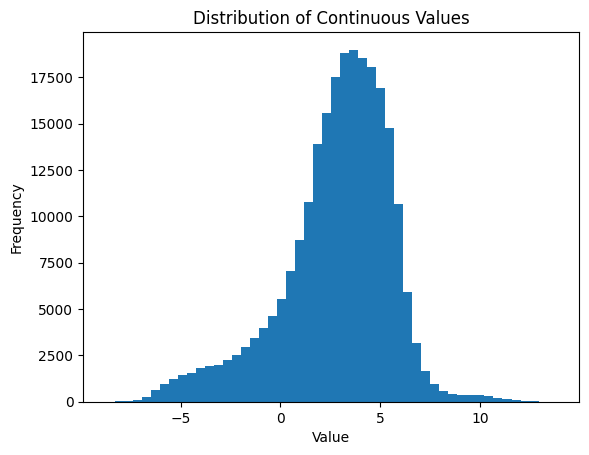

In [28]:
import matplotlib.pyplot as plt

# x = your NumPy array
plt.hist(y, bins=50)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of Continuous Values")
plt.show()

In [29]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (193535, 750)
Test set shape: (48500, 750)


In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('ohe', OneHotEncoder(
                    handle_unknown='ignore',
                    min_frequency=50,
                    sparse_output=False
                ))
            ]),
            cat_cols
        ),
        ('num', StandardScaler(), num_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

In [31]:
# these are not the final TUNED models

models = {
    'ElasticNet (baseline)': ElasticNet(
        alpha=0.01,
        l1_ratio=0.5,
        max_iter=2000,
        random_state=42
    ),
    'LightGBM (strong)': LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=127,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.4,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ),
}

preds = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds[name] = pipe.predict(X_test)

    rmse = float(np.sqrt(mean_squared_error(y_test, preds[name])))
    mae = float(mean_absolute_error(y_test, preds[name]))
    r2 = float(r2_score(y_test, preds[name]))

    print()
    print(name)
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")


ElasticNet (baseline)
RMSE: 2.0368
MAE:  1.6327
R²:   0.4581


c:\Users\shibu\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



LightGBM (strong)
RMSE: 1.3265
MAE:  1.0013
R²:   0.7702


In [32]:
# This is for CATBOOST

cb_model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=0
)

cat_feature_indices = [i for i, col in enumerate(feature_cols) if col in cat_cols]

X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

for col in cat_cols:
    X_train_cb[col] = X_train_cb[col].fillna('Unknown').astype(str)
    X_test_cb[col] = X_test_cb[col].fillna('Unknown').astype(str)

for col in num_cols:
    X_train_cb[col] = X_train_cb[col].fillna(0)
    X_test_cb[col] = X_test_cb[col].fillna(0)

cb_model.fit(X_train_cb, y_train, cat_features=cat_feature_indices)
cb_pred = cb_model.predict(X_test_cb)

preds['CatBoost (primary)'] = cb_pred

rmse = float(np.sqrt(mean_squared_error(y_test, cb_pred)))
mae = float(mean_absolute_error(y_test, cb_pred))
r2 = float(r2_score(y_test, cb_pred))

print()
print("CatBoost (primary)")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")


CatBoost (primary)
RMSE: 1.4888
MAE:  1.1343
R²:   0.7105


In [33]:
# sample output table
n_show = 25

sample = X_test.head(n_show).copy()
sample['CELL_LINE_NAME'] = df_genomic.loc[X_test.index[:n_show], 'CELL_LINE_NAME'].values
sample['DRUG_NAME'] = df_genomic.loc[X_test.index[:n_show], 'DRUG_NAME'].values
sample['Actual_LN_IC50'] = y_test[:n_show].round(4)

sample['ElasticNet_Pred'] = preds['ElasticNet (baseline)'][:n_show].round(4)
sample['LightGBM_Pred'] = preds['LightGBM (strong)'][:n_show].round(4)
sample['CatBoost_Pred'] = preds['CatBoost (primary)'][:n_show].round(4)

sample['Interpretation'] = sample['LightGBM_Pred'].apply(
    lambda x: 'Sensitive' if x < 0 else 'Resistant'
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)

print(f"Sample predictions for the first {n_show} test rows:")
print(sample[
    [
        'CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_NAME',
        'TARGET_PATHWAY', 'Actual_LN_IC50',
        'ElasticNet_Pred', 'LightGBM_Pred', 'CatBoost_Pred',
        'Interpretation'
    ]
].to_string(index=True))

Sample predictions for the first 25 test rows:
   CELL_LINE_NAME     TCGA_DESC     DRUG_NAME   TARGET_PATHWAY  Actual_LN_IC50  ElasticNet_Pred  LightGBM_Pred  CatBoost_Pred Interpretation
3           EW-11  UNCLASSIFIED  Camptothecin  DNA replication         -3.7420          -0.6783        -4.6638        -2.6178      Sensitive
5        COLO-829          SKCM  Camptothecin  DNA replication         -1.2350          -0.4112        -2.2557        -1.6938      Sensitive
9          TCCSUP          BLCA  Camptothecin  DNA replication         -2.3506          -0.5741        -2.1939        -1.5749      Sensitive
14        8-MG-BA           GBM  Camptothecin  DNA replication         -4.2563          -0.1804        -2.0036        -1.6317      Sensitive
18       U-118-MG           GBM  Camptothecin  DNA replication         -3.3540          -0.0649        -2.0014        -1.5066      Sensitive
20          YKG-1           GBM  Camptothecin  DNA replication         -2.7844          -0.8393        -2.9